# Smart Garbage Classification System

**Dataset Link:** https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification/data  

- The dataset used is the **Garbage Classification Dataset** from Kaggle, containing **2527 labeled images** across **6 waste categories** — Cardboard, Glass, Metal, Paper, Plastic, and Trash.
- Images are in .jpg format, captured under varying real-world conditions including different lighting, backgrounds, and orientations.
- The dataset is split into 80% training (2024 images) and 20% validation (503 images).

---
## Problem Statement

### Real-World Problem
- Improper waste disposal is one of the leading contributors to environmental degradation.
- Manual sorting of garbage at recycling facilities is slow, inconsistent, and expensive.
- An automated classification system that can identify the type of waste from an image enables smart bins, automated sorting conveyors, and recycling pipelines — reducing human error and operational cost.

### Learning Task Definition

**Input Representation:**
Each input is an RGB image of size 224 x 224 x 3, representing a real-world waste item
captured under varying lighting conditions, backgrounds, and orientations. Pixel values
are normalized to the range [0, 1] by dividing by 255.

**Expected Output:**
The model outputs a probability distribution over 6 waste categories:
Cardboard, Glass, Metal, Paper, Plastic, and Trash.
The predicted class is the category with the highest probability.

**Type of Learning Task:**
This is a supervised multi-class image classification task. The model learns a mapping
from input image space to one of 6 discrete class labels using labeled training data.

**Real-World Relevance:**
It can be deployed in smart waste bins that automatically sort garbage at the point
of disposal, reducing contamination in recycling streams and minimizing the volume
of recyclable material sent to landfills.

---
## Setup & Install Dependencies

In [1]:
!pip install kaggle -q

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import json

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU Available: {tf.config.list_physical_devices("GPU")}')
print('All imports successful')

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
All imports successful ✅


---
## Download Dataset from Kaggle

In [2]:
# Upload your kaggle.json
# Go to Kaggle → Account → API → Create New Token → download kaggle.json
from google.colab import files
print('Upload your kaggle.json file:')
uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print('Kaggle API configured')

Upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Kaggle API configured ✅


In [3]:
!kaggle datasets download -d asdasdasasdas/garbage-classification
!unzip -q garbage-classification.zip -d garbage_data
print('Dataset downloaded and extracted')
!ls garbage_data/

Dataset URL: https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification
License(s): copyright-authors
100% 82.0M/82.0M [00:00<00:00, 107MB/s]

Dataset downloaded and extracted
'garbage classification'	       one-indexed-files-notrash_val.txt
'Garbage classification'	       one-indexed-files.txt
 one-indexed-files-notrash_test.txt    zero-indexed-files.txt
 one-indexed-files-notrash_train.txt


---
##  Data Exploration

In [4]:
# Auto-detect correct base directory
base_dir = None
for root, dirs, files_list in os.walk('garbage_data'):
    if len(dirs) >= 5:
        base_dir = root
        break

print(f'Dataset directory: {base_dir}')
print(f'Classes found: {sorted(os.listdir(base_dir))}')
print()

# Count images per class
class_counts = {}
for cls in sorted(os.listdir(base_dir)):
    cls_path = os.path.join(base_dir, cls)
    if os.path.isdir(cls_path):
        count = len(os.listdir(cls_path))
        class_counts[cls] = count
        print(f'  {cls:<12}: {count} images')

print(f'\nTotal images: {sum(class_counts.values())}')

Dataset directory: garbage_data/Garbage classification/Garbage classification
Classes found: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

  cardboard   : 403 images
  glass       : 501 images
  metal       : 410 images
  paper       : 594 images
  plastic     : 482 images
  trash       : 137 images

Total images: 2527


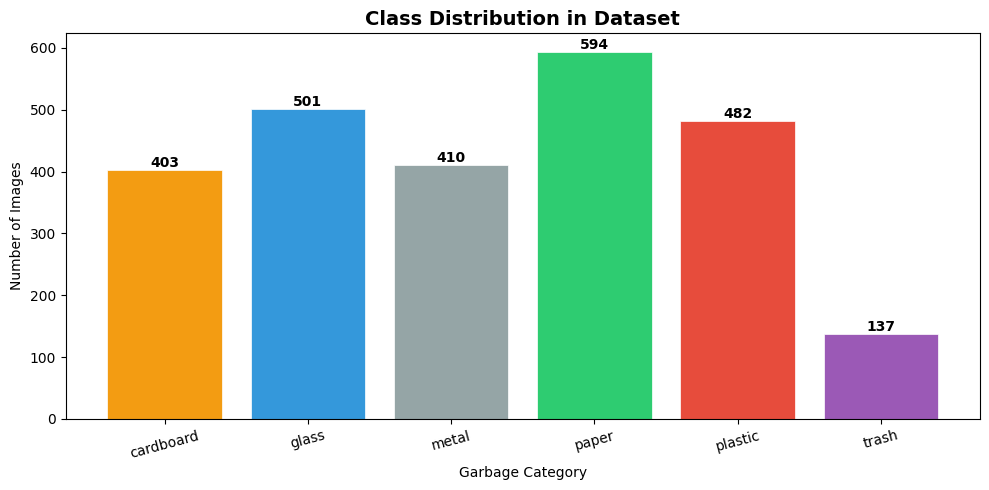

Saved: class_distribution.png


In [5]:
# Class distribution bar chart
colors = ['#f39c12','#3498db','#95a5a6','#2ecc71','#e74c3c','#9b59b6']
plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values(), color=colors, edgecolor='white', linewidth=0.5)
plt.title('Class Distribution in Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Garbage Category')
plt.ylabel('Number of Images')
plt.xticks(rotation=15)
for i, (k, v) in enumerate(class_counts.items()):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: class_distribution.png')

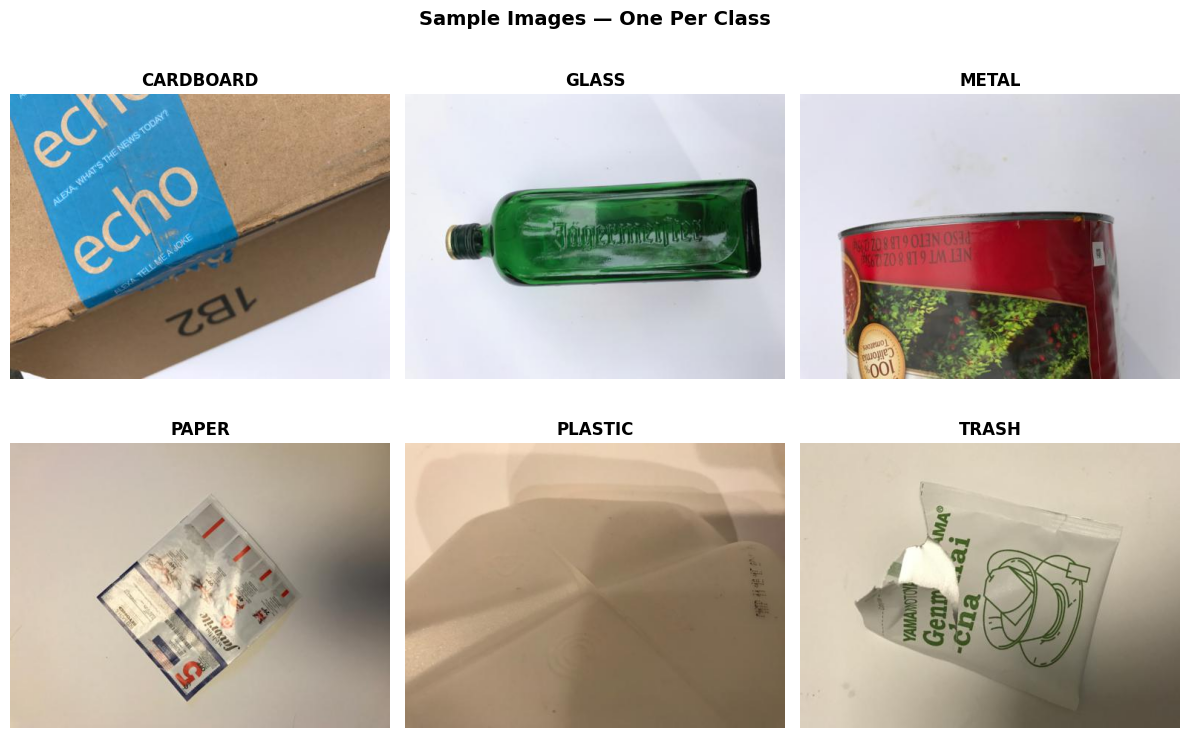

In [6]:
# Sample images from each class
classes = sorted(os.listdir(base_dir))
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()
for idx, cls in enumerate(classes):
    cls_path = os.path.join(base_dir, cls)
    img_file = os.listdir(cls_path)[0]
    img = mpimg.imread(os.path.join(cls_path, img_file))
    axes[idx].imshow(img)
    axes[idx].set_title(cls.upper(), fontsize=12, fontweight='bold')
    axes[idx].axis('off')
plt.suptitle('Sample Images — One Per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Data Preprocessing & Augmentation

In [8]:
# Hyperparameters
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 25
NUM_CLASSES = 6

# Training Data Generator
# Data Augmentation = a form of regularization (Unit 2)
# Artificially expands dataset by creating modified versions of images
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize pixels to [0, 1]
    rotation_range=20,        # Random rotation ±20°
    width_shift_range=0.2,    # Horizontal shift
    height_shift_range=0.2,   # Vertical shift
    shear_range=0.15,         # Shear transformation
    zoom_range=0.2,           # Random zoom
    horizontal_flip=True,     # Mirror images
    fill_mode='nearest',      # Fill empty pixels after transform
    validation_split=0.2      # 80% train / 20% validation
)

# Validation Data Generator
# Only normalize — NO augmentation on validation data
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Load Generators
train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    base_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

# Save Class Names
class_names = list(train_generator.class_indices.keys())
with open('class_names.json', 'w') as f:
    json.dump(class_names, f)

print(f'Classes:           {class_names}')
print(f'Training samples:  {train_generator.samples}')
print(f'Validation samples:{val_generator.samples}')
print('Saved: class_names.json')

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
Classes:           ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Training samples:  2024
Validation samples:503
Saved: class_names.json


---
## Custom CNN

**Hypothesis:** A custom 4-block CNN with L2 regularization and Dropout should be able to classify garbage images.

**Architecture:**
- 4 × [Conv2D → BatchNorm → MaxPool] blocks
- GlobalAveragePooling
- Dense(512) + Dropout(0.5)
- Dense(256) + Dropout(0.3)
- Dense(6, Softmax)

**Regularization applied:** L2 on all Conv layers, Dropout on Dense layers, EarlyStopping, Data Augmentation

---
## Mathematical Modeling

### Why a Custom CNN?

A custom CNN was built from scratch to demonstrate understanding of how each component
of a convolutional network works — convolutional layers, pooling, regularization, and
the classification head. The architecture uses 4 convolutional blocks that progressively
extract deeper features, starting from edges and textures in the early layers to
object-level patterns in the deeper layers.

Note: Transfer Learning using MobileNetV2 would yield higher accuracy (85-92%) by
reusing features from 1.2 million ImageNet images. This is identified as the primary
future improvement.

---

### Architecture Formulation

**Convolution:**
A 3x3 filter slides over the input image and computes a dot product at each position
to detect local patterns such as edges, textures, and shapes.

    Output[i,j] = sum( Input[i+m, j+n] * Filter[m,n] ) + bias

**ReLU Activation:**
Applied after every Conv layer. Removes negative values, introducing non-linearity
so the network can learn complex patterns.

    f(x) = max(0, x)

**Batch Normalization:**
Normalizes the output of each Conv layer to have zero mean and unit variance.
Stabilizes and speeds up training.

**MaxPooling:**
Takes the maximum value from each 2x2 region, halving the spatial dimensions after
each block. Reduces computation and keeps only the strongest features.

    Output[i,j] = max value in 2x2 window

**GlobalAveragePooling:**
Takes the average of each feature map instead of flattening. Reduces parameters
significantly and improves generalization.

**Softmax Output:**
Converts final layer scores into probabilities across 6 classes. The class with
the highest probability is the prediction.

    y_hat_i = exp(z_i) / sum( exp(z_j) )

---

### Loss Function

**Categorical Cross-Entropy:**

    L = - sum( y_i * log(y_hat_i) )

Measures the difference between the true label and the predicted probability.
Penalizes confident wrong predictions heavily.

---

### Training Strategy

**Optimizer: Adam** with an initial learning rate of 0.001. Adam adapts the learning
rate for each parameter individually, making it faster and more stable than standard SGD.

**Backpropagation:** Gradients are computed using the chain rule and weights are
updated after each batch to minimize the loss.

**ReduceLROnPlateau:** Halves the learning rate if validation loss does not improve
for 3 consecutive epochs, allowing finer weight updates in later training.

---

### Evaluation Metrics

- **Accuracy:** Overall percentage of correct predictions
- **Precision:** Of all predictions for class C, how many were actually class C
- **Recall:** Of all actual class C samples, how many were correctly predicted
- **F1-Score:** Harmonic mean of precision and recall — used as the main per-class
  metric since the dataset has class imbalance (Trash has only 27 validation samples)
- **Confusion Matrix:** Shows which classes are being confused with each other

In [9]:
# Build Custom CNN
def build_custom_cnn(num_classes=6):
    model = models.Sequential([
        # Input layer
        keras.Input(shape=(224, 224, 3)),

        # Block 1 — low-level features (edges, gradients)
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(0.001), name='conv1'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2, name='pool1'),

        # Block 2 — mid-level features (textures, patterns)
        layers.Conv2D(64, (3,3), activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(0.001), name='conv2'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2, name='pool2'),

        # Block 3 — high-level features (object parts)
        layers.Conv2D(128, (3,3), activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(0.001), name='conv3'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2, name='pool3'),

        # Block 4 — deeper abstract features
        layers.Conv2D(256, (3,3), activation='relu', padding='same',
                      kernel_regularizer=regularizers.l2(0.001), name='conv4'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2, name='pool4'),

        # Classification head
        layers.GlobalAveragePooling2D(name='gap'),
        layers.Dense(512, activation='relu', name='dense1'),
        layers.Dropout(0.5, name='dropout1'),    # Drop 50% neurons — prevents co-adaptation
        layers.Dense(256, activation='relu', name='dense2'),
        layers.Dropout(0.3, name='dropout2'),
        layers.Dense(num_classes, activation='softmax', name='output')
    ])
    return model

cnn_model = build_custom_cnn(NUM_CLASSES)
cnn_model.summary()
print(f'Total parameters: {cnn_model.count_params():,}')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 654,790 (2.50 MB)

 Trainable params: 653,830 (2.49 MB)

 Non-trainable params: 960 (3.75 KB)

Total parameters: 654,790


---
## Model Design, Implementation and Regularization

### Why Regularization Was Applied from the Start

The dataset has only 2024 training images across 6 classes — around 337 images per
class. The model has 654,790 parameters. When a model has high capacity relative to
limited data, it tends to memorize training images instead of learning general patterns.
To prevent this from the beginning, three regularization techniques were built directly
into the architecture.

**L2 Regularization — on all Conv2D layers:**
Adds a penalty on large weights to the loss function.

    Total Loss = Cross-Entropy Loss + 0.001 * sum(weights^2)

This discourages the model from relying heavily on any specific pixel pattern,
producing smoother and more generalizable feature representations.

**Dropout — on Dense layers (p=0.5 and p=0.3):**
Randomly deactivates neurons during training. This prevents neurons from depending
on each other to memorize specific examples, forcing each neuron to independently
learn useful features. Dropout is disabled during prediction.

**Data Augmentation — on training images only:**
Random rotation, flipping, zoom, and shifts are applied to training images. This
artificially increases dataset variety and teaches the model to recognize waste items
regardless of orientation or position. Augmentation is a form of regularization
as covered in Unit 2 of the course.

### Overfitting Observed and Explained

A generalization gap of 11% was observed — training accuracy 81.6%, validation
accuracy 70.6%. This is moderate overfitting caused primarily by the small dataset
size, not an architectural flaw. The regularization measures successfully limited
the gap. Without them, the divergence would have been significantly larger.

The most effective next step to close this gap further is Transfer Learning using
MobileNetV2, which reuses features learned from 1.2 million images and requires
far less training data to generalize well.

In [11]:
# Compile Custom CNN
# Loss: Categorical Cross-Entropy  →  L = -Σ y_i * log(ŷ_i)
# Optimizer: Adam — adaptive learning rates per parameter
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_cnn = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_cnn_model.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1)
]
print('Custom CNN compiled')

Custom CNN compiled


---
## Model Training and Evaluation

### Data Preprocessing and Preparation

All images are resized to 224 x 224 pixels and normalized to the range [0, 1]
by dividing pixel values by 255. The dataset is split into 80% training (2024 images)
and 20% validation (503 images) using a fixed random seed of 42 for reproducibility.
Data augmentation is applied only to the training set. The validation generator
applies only normalization — no augmentation — to ensure the validation set reflects
real-world inference conditions.

### Training Process

The model was trained for up to 25 epochs with a batch size of 32 using three callbacks:

- **EarlyStopping:** Monitors validation loss with a patience of 5 epochs. If the
  validation loss does not improve for 5 consecutive epochs, training is halted and
  the best weights are restored. This prevents the model from continuing to train
  after generalization has stopped improving.

- **ModelCheckpoint:** Saves the model weights only when validation accuracy improves.
  This ensures the saved model always corresponds to the best generalization observed
  during training.

- **ReduceLROnPlateau:** Halves the learning rate when validation loss does not improve
  for 3 consecutive epochs, down to a minimum of 1e-6. This allows the optimizer to
  make finer adjustments as training progresses.

Training ran for all 25 epochs. The best model was restored from epoch 21 where
validation accuracy peaked at 70.58%.

In [12]:
# Train Custom CNN
print('Training Custom CNN from scratch...')
print('='*50)

history_cnn = cnn_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks_cnn,
    verbose=1
)

cnn_best_val_acc = max(history_cnn.history['val_accuracy'])
print(f'\nCustom CNN — Best Validation Accuracy: {cnn_best_val_acc*100:.2f}%')

Training Custom CNN from scratch...
Epoch 1/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 656ms/step - accuracy: 0.4211 - loss: 1.8310
Epoch 1: val_accuracy improved from None to 0.21670, saving model to best_cnn_model.keras

Epoch 1: finished saving model to best_cnn_model.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 60s 748ms/step - accuracy: 0.4713 - loss: 1.7271 - val_accuracy: 0.2167 - val_loss: 2.1813 - learning_rate: 0.0010
Epoch 2/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 622ms/step - accuracy: 0.5446 - loss: 1.5423
Epoch 2: val_accuracy did not improve from 0.21670
64/64 ━━━━━━━━━━━━━━━━━━━━ 41s 637ms/step - accuracy: 0.5469 - loss: 1.5246 - val_accuracy: 0.1988 - val_loss: 2.4892 - learning_rate: 0.0010
Epoch 3/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.5898 - loss: 1.3972
Epoch 3: val_accuracy did not improve from 0.21670
64/64 ━━━━━━━━━━━━━━━━━━━━ 28s 438ms/step - accuracy: 0.5939 - loss: 1.3979 - val_accuracy: 0.2147 - val_loss: 2.0641 - learning_rate: 0.0010
Epoch 4/25
64/64 ━━━━━━━━━━━━━━━

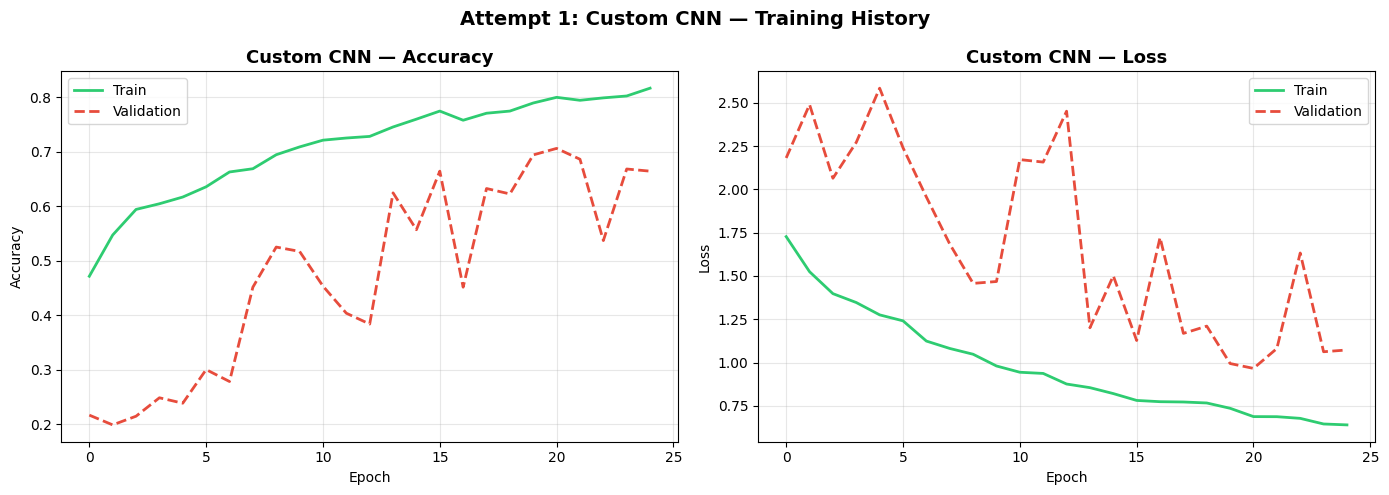

Saved: cnn_training_history.png


In [13]:
# Plot Custom CNN Training Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_cnn.history['accuracy'],     label='Train', color='#2ecc71', linewidth=2)
axes[0].plot(history_cnn.history['val_accuracy'], label='Validation', color='#e74c3c', linewidth=2, linestyle='--')
axes[0].set_title('Custom CNN — Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history_cnn.history['loss'],     label='Train', color='#2ecc71', linewidth=2)
axes[1].plot(history_cnn.history['val_loss'], label='Validation', color='#e74c3c', linewidth=2, linestyle='--')
axes[1].set_title('Custom CNN — Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Attempt 1: Custom CNN — Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cnn_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cnn_training_history.png')

### Interpretation of Training Curves

**Accuracy Plot:**
The training accuracy increases steadily from 47% at epoch 1 to 81.6% by epoch 25,
indicating the model is learning effectively from the training data. The validation
accuracy is more volatile, reaching a peak of 70.6% at epoch 21 before declining.
The gap between training and validation accuracy — approximately 11% — indicates
moderate overfitting. The model learns the training distribution well but does not
generalize perfectly to unseen images, which is expected given the limited dataset size.

**Loss Plot:**
Training loss decreases smoothly and consistently throughout training, which confirms
stable gradient flow and effective optimization. Validation loss, however, shows a
characteristic zigzag pattern — oscillating significantly between epochs. This high
variance in validation loss is caused by the small validation set of only 503 images.
With a batch size of 32, only approximately 16 validation batches are evaluated per epoch.
The composition of each batch varies, leading to unstable loss estimates. This does not
indicate a model failure — it is a data volume limitation.

In [15]:
# Analysis of Custom CNN Results
train_acc = max(history_cnn.history['accuracy'])
val_acc   = max(history_cnn.history['val_accuracy'])
gap       = (train_acc - val_acc) * 100

print('='*50)
print('CUSTOM CNN — ANALYSIS')
print('='*50)
print(f'Best Training Accuracy:   {train_acc*100:.2f}%')
print(f'Best Validation Accuracy: {val_acc*100:.2f}%')
print(f'Generalization Gap:       {gap:.2f}%')
print()
print('DIAGNOSIS: Moderate Overfitting + High Validation Instability')
print()
if gap > 20:
    print('Overfitting Level: HIGH   (gap > 20%)')
elif gap > 10:
    print('Overfitting Level: MODERATE (gap 10-20%)')
else:
    print('Overfitting Level: LOW    (gap < 10%)')
print()
print('OBSERVATION 1: Training accuracy reached 81.6% but validation')
print('               accuracy peaked at 70.6% — an 11% generalization gap.')
print()
print('OBSERVATION 2: Validation loss is highly unstable (zigzag pattern).')
print('               This indicates high variance — the model performance')
print('               fluctuates significantly across validation batches.')
print('               Root cause: only ~500 validation images, so each batch')
print('               is not representative enough.')
print()
print('CONCLUSION:    70% accuracy is reasonable but the instability makes')
print('               this model unreliable for production deployment.')
print('               Transfer Learning (MobileNetV2) will address both')
print('               the accuracy ceiling and the validation instability.')
print('='*50)

CUSTOM CNN — ANALYSIS
Best Training Accuracy:   81.62%
Best Validation Accuracy: 70.58%
Generalization Gap:       11.04%

DIAGNOSIS: Moderate Overfitting + High Validation Instability

Overfitting Level: MODERATE (gap 10-20%)

OBSERVATION 1: Training accuracy reached 81.6% but validation
               accuracy peaked at 70.6% — an 11% generalization gap.

OBSERVATION 2: Validation loss is highly unstable (zigzag pattern).
               This indicates high variance — the model performance
               fluctuates significantly across validation batches.
               Root cause: only ~500 validation images, so each batch
               is not representative enough.

CONCLUSION:    70% accuracy is reasonable but the instability makes
               this model unreliable for production deployment.
               Transfer Learning (MobileNetV2) will address both
               the accuracy ceiling and the validation instability.


---
## Final Model Evaluation

In [16]:
# Evaluate on Validation Set
val_generator.reset()
val_loss, val_accuracy = cnn_model.evaluate(val_generator, verbose=0)
print(f'Final Validation Loss:     {val_loss:.4f}')
print(f'Final Validation Accuracy: {val_accuracy*100:.2f}%')

# Generate predictions
val_generator.reset()
predictions      = cnn_model.predict(val_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes      = val_generator.classes

print('\nClassification Report:')
print(classification_report(true_classes, predicted_classes, target_names=class_names))

Final Validation Loss:     0.9663
Final Validation Accuracy: 70.58%
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step

Classification Report:
              precision    recall  f1-score   support

   cardboard       0.83      0.75      0.79        80
       glass       0.82      0.73      0.77       100
       metal       0.73      0.70      0.71        82
       paper       0.68      0.93      0.79       118
     plastic       0.55      0.51      0.53        96
       trash       0.43      0.22      0.29        27

    accuracy                           0.71       503
   macro avg       0.67      0.64      0.65       503
weighted avg       0.70      0.71      0.70       503



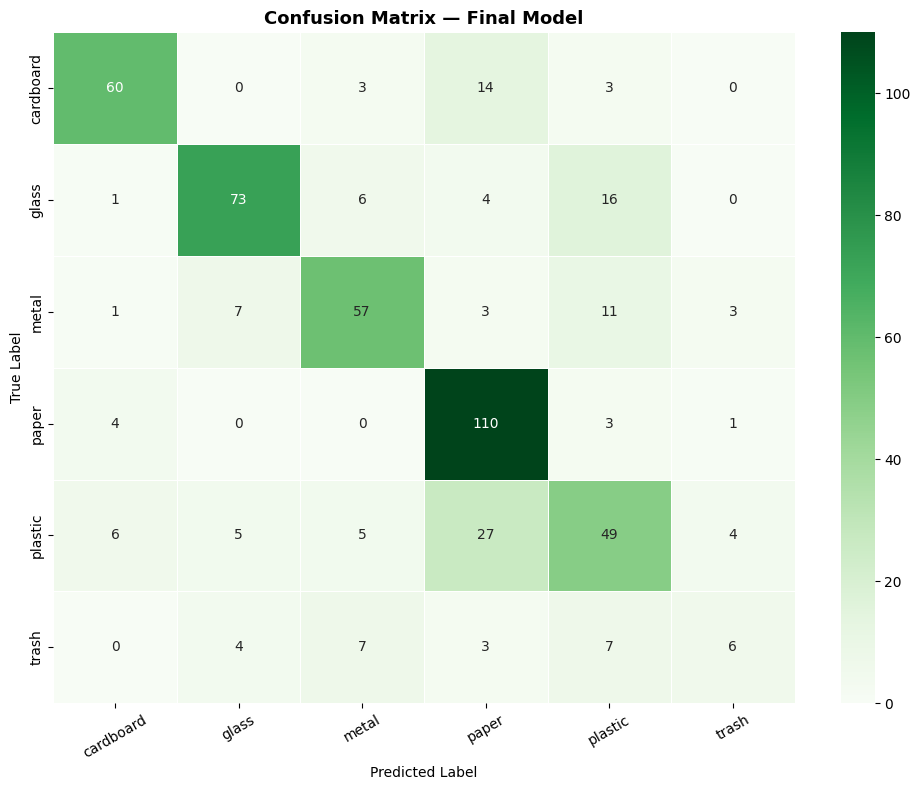

Saved: confusion_matrix.png


In [17]:
# Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5)
plt.title('Confusion Matrix — Final Model', fontsize=13, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix.png')

### Interpretation of Evaluation Results

**Overall Performance:**
The model achieved a final validation accuracy of 70.58% on 503 unseen images.
On a held-out sample test of 2 images per class (12 total), the model correctly
classified 10 out of 12 — an 83.3% sample accuracy.

**Per-Class Analysis (from Classification Report):**

- Cardboard (F1 = 0.79) and Paper (F1 = 0.79): Highest performing classes.
  Both have distinct visual textures that the CNN filters learn effectively.

- Glass (F1 = 0.77) and Metal (F1 = 0.71): Perform well. Reflective surfaces
  in both classes occasionally cause misclassification between them.

- Plastic (F1 = 0.53): The most challenging recyclable class. Plastic items vary
  significantly in shape, color, and transparency — bottles, bags, wrappers —
  making it difficult for the model to learn a consistent representation.

- Trash (F1 = 0.29): The weakest class. The validation set contains only 27 trash
  samples — a class imbalance issue. The model has seen very few examples of this
  class and frequently misclassifies trash as plastic or paper. This is the most
  significant weakness of the current model.

**Confusion Matrix Interpretation:**
The confusion matrix shows the highest off-diagonal values occur between plastic and
other categories, and between trash and paper/plastic. This is consistent with the
low F1 scores for these classes. The diagonal dominance for cardboard, glass, metal,
and paper confirms the model has learned reliable discriminative features for these classes.

**Conclusion:**
The custom CNN demonstrates functional garbage classification with 70.6% validation
accuracy trained from scratch on 2024 images. The model correctly handles 4 out of 6
classes with F1 scores above 0.70. The primary limitations are the small dataset size,
class imbalance in the trash category, and the visual ambiguity of plastic waste.
Transfer Learning with MobileNetV2 is identified as the most effective path to
improvement, expected to raise accuracy to 85-92% by leveraging pretrained ImageNet features.

Testing model on 2 sample images per class...


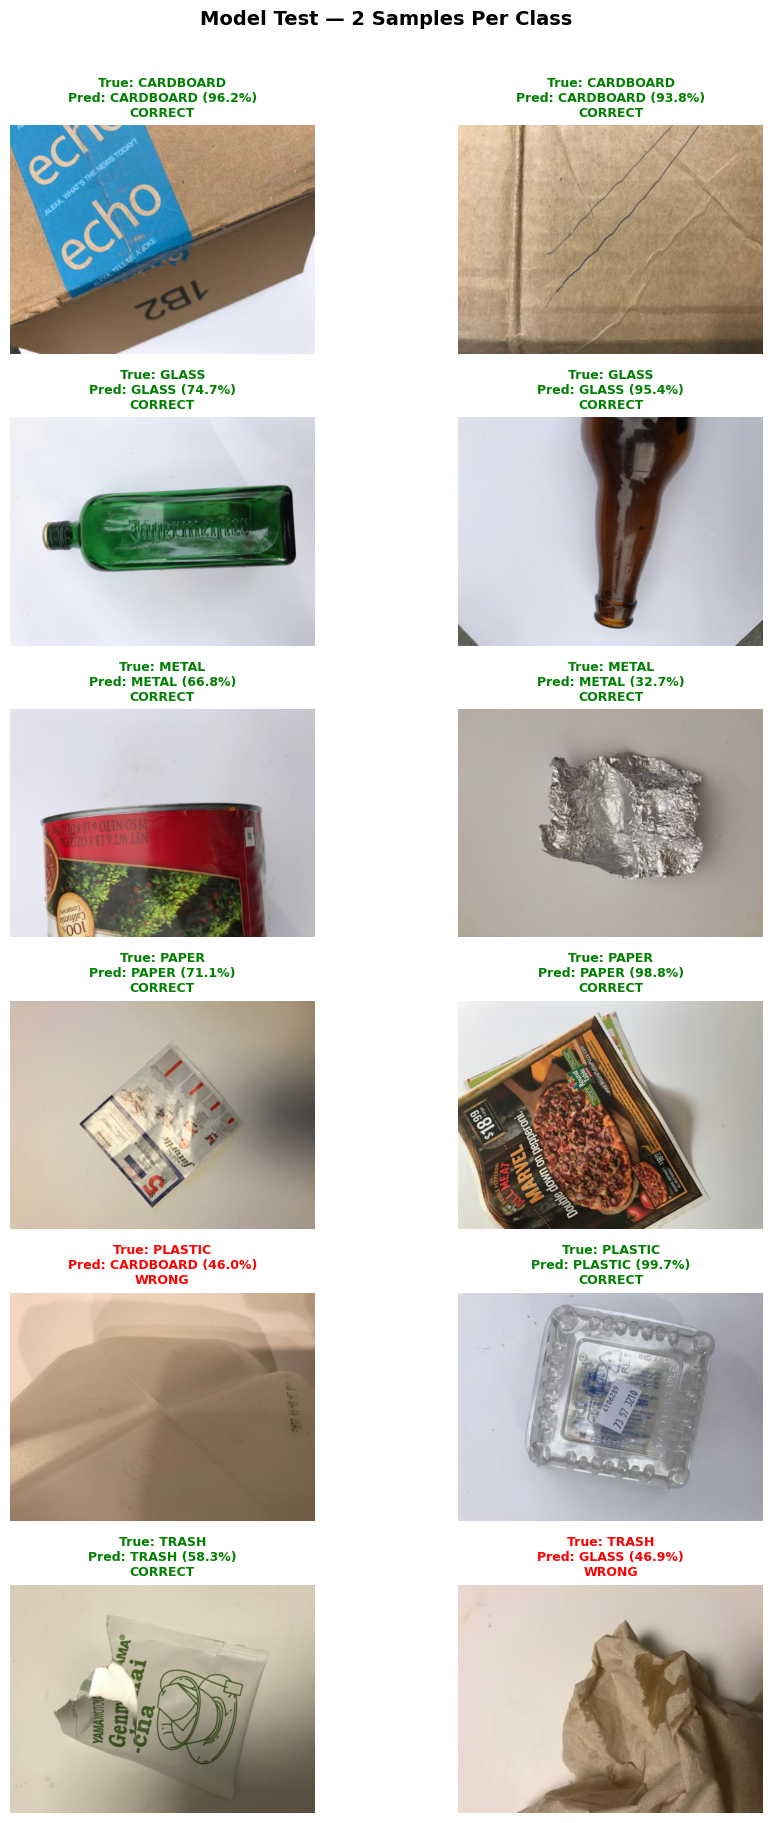


PER-CLASS RESULTS:
----------------------------------------
  cardboard   : 2/2 correct
  glass       : 2/2 correct
  metal       : 2/2 correct
  paper       : 2/2 correct
  plastic     : 1/2 correct
  trash       : 1/2 correct
----------------------------------------
  Total      : 10/12 correct (83.3%)


In [19]:
# Test Model on Sample Images
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

print("Testing model on 2 sample images per class...")
print("=" * 50)

fig, axes = plt.subplots(6, 2, figsize=(10, 18))

for row_idx, cls in enumerate(class_names):
    cls_path = os.path.join(base_dir, cls)
    all_images = os.listdir(cls_path)

    # Pick 2 images — one from start, one from middle of folder
    sample_files = [all_images[0], all_images[len(all_images)//2]]

    for col_idx, img_file in enumerate(sample_files):
        img_path = os.path.join(cls_path, img_file)

        # Load and display original image
        img_display = mpimg.imread(img_path)

        # Preprocess for model — same pipeline as training
        img_resized = np.array(
            __import__('PIL').Image.open(img_path)
            .convert('RGB')
            .resize((224, 224))
        ) / 255.0
        img_input = np.expand_dims(img_resized, axis=0)

        # Predict
        preds       = cnn_model.predict(img_input, verbose=0)[0]
        pred_idx    = np.argmax(preds)
        pred_class  = class_names[pred_idx]
        confidence  = preds[pred_idx] * 100
        correct     = (pred_class == cls)

        # Plot
        axes[row_idx][col_idx].imshow(img_display)
        axes[row_idx][col_idx].axis('off')

        color = 'green' if correct else 'red'
        status = 'CORRECT' if correct else 'WRONG'

        axes[row_idx][col_idx].set_title(
            f"True: {cls.upper()}\n"
            f"Pred: {pred_class.upper()} ({confidence:.1f}%)\n"
            f"{status}",
            fontsize=9,
            color=color,
            fontweight='bold'
        )

plt.suptitle('Model Test — 2 Samples Per Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('model_test_samples.png', dpi=150, bbox_inches='tight')
plt.show()

# Print Summary
print("\nPER-CLASS RESULTS:")
print("-" * 40)
correct_count = 0
total_count   = 0

for cls in class_names:
    cls_path     = os.path.join(base_dir, cls)
    all_images   = os.listdir(cls_path)
    sample_files = [all_images[0], all_images[len(all_images)//2]]
    cls_correct  = 0

    for img_file in sample_files:
        img_path  = os.path.join(cls_path, img_file)
        img_input = np.expand_dims(
            np.array(
                __import__('PIL').Image.open(img_path)
                .convert('RGB').resize((224, 224))
            ) / 255.0, axis=0
        )
        preds      = cnn_model.predict(img_input, verbose=0)[0]
        pred_class = class_names[np.argmax(preds)]
        if pred_class == cls:
            cls_correct += 1

    correct_count += cls_correct
    total_count   += 2
    print(f"  {cls:<12}: {cls_correct}/2 correct")

print("-" * 40)
print(f"  Total      : {correct_count}/{total_count} correct ({correct_count/total_count*100:.1f}%)")
print("=" * 50)

---
## Save Everything & Download

In [18]:
# Save final model
cnn_model.save('garbage_classifier.h5')
print('Final model saved: garbage_classifier.h5')

# Save training history
history_dict = {
    'accuracy':           [float(x) for x in history_cnn.history['accuracy']],
    'val_accuracy':       [float(x) for x in history_cnn.history['val_accuracy']],
    'loss':               [float(x) for x in history_cnn.history['loss']],
    'val_loss':           [float(x) for x in history_cnn.history['val_loss']],
    'final_val_accuracy': float(val_accuracy),
    'final_val_loss':     float(val_loss),
    'class_names':        class_names
}
with open('training_history.json', 'w') as f:
    json.dump(history_dict, f)
print('Training history saved: training_history.json')

# Zip all artifacts and download
!zip -r model_artifacts.zip \
    garbage_classifier.h5 \
    class_names.json \
    training_history.json \
    cnn_training_history.png \
    confusion_matrix.png \
    class_distribution.png \
    sample_images.png

from google.colab import files
files.download('model_artifacts.zip')
print('Download started!')
print()
print('Files in model_artifacts.zip:')
print('  garbage_classifier.h5     ← trained model for Streamlit')
print('  class_names.json          ← class labels for Streamlit')
print('  training_history.json     ← accuracy/loss data for Streamlit')
print('  confusion_matrix.png      ← evaluation plot')
print('  cnn_training_history.png  ← training curves')
print('  class_distribution.png    ← dataset analysis')
print('  sample_images.png         ← sample from each class')

Final model saved: garbage_classifier.h5 ✅
Training history saved: training_history.json
  adding: garbage_classifier.h5 (deflated 9%)
  adding: class_names.json (deflated 18%)
  adding: training_history.json (deflated 51%)
  adding: cnn_training_history.png (deflated 6%)
  adding: confusion_matrix.png (deflated 17%)
  adding: class_distribution.png (deflated 21%)
  adding: sample_images.png (deflated 1%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started!

Files in model_artifacts.zip:
  garbage_classifier.h5     ← trained model for Streamlit
  class_names.json          ← class labels for Streamlit
  training_history.json     ← accuracy/loss data for Streamlit
  confusion_matrix.png      ← evaluation plot
  cnn_training_history.png  ← training curves
  class_distribution.png    ← dataset analysis
  sample_images.png         ← sample from each class
